# Figure 2D: seasonal extrapolation ranking

Interactive companion to `plot_fig2d_seasonal_rank.py`. Run the cells in order. The notebook recomputes MAE (L1), MSE (L2), Pearson r, Spearman ρ, and R-squared from the saved identity-free test predictions, ranks models within each season and metric, then exports the matrix figure.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import SVG, display

CODE_DIR = Path.cwd().resolve()
if not (CODE_DIR / 'plot_fig2d_seasonal_rank.py').exists():
    CODE_DIR = Path('/home/chenyh/workspace/fluProfiler/paper/Code')
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import plot_fig2d_seasonal_rank as fig2d
pd.set_option('display.precision', 4)

## Settings

Edit these paths only if you want to analyse another completed result directory or save a separate copy.

In [2]:
RESULTS_ROOT = fig2d.DEFAULT_RESULTS_ROOT
OUTPUT_DIR = CODE_DIR / 'Fig2_seasonal_rank'

print(f'Results: {RESULTS_ROOT}')
print(f'Output:  {OUTPUT_DIR}')

Results: /home/chenyh/workspace/fluProfiler/results/H3_HA1_v1.0/20260827_112805
Output:  /home/chenyh/workspace/fluProfiler/paper/Code/Fig2_seasonal_rank


## Recompute metrics and inspect ranks

Each seasonal metric group must contain ranks 1, 2, and 3. This cell checks that condition before plotting.

In [3]:
values = fig2d.collect_seasonal_metrics(RESULTS_ROOT)
rank_check = values.groupby(['season', 'metric'])['rank'].apply(lambda ranks: sorted(ranks.tolist()))
assert rank_check.apply(lambda ranks: ranks == [1, 2, 3]).all(), 'A seasonal metric group does not have ranks 1, 2, 3.'

display(values.sort_values(['season_id', 'metric', 'rank']))
display(values.pivot(index=['season', 'metric'], columns='model', values='rank'))
summary = (values.groupby('model')['rank']
           .agg(mean_rank='mean', top2_count=lambda ranks: (ranks <= 2).sum())
           .assign(top2_of_30=lambda frame: frame['top2_count'].astype(str) + '/30'))
display(summary)

,season_id,season,model,metric,value,n_test_pairs,rank
0,39,2023NH,fluProfiler,MAE,0.9318,3432,1
5,39,2023NH,AdaBoost,MAE,1.0496,3432,2
10,39,2023NH,Nextflu,MAE,1.1372,3432,3
1,39,2023NH,fluProfiler,MSE,1.3709,3432,1
6,39,2023NH,AdaBoost,MSE,1.9445,3432,2
...,...,...,...,...,...,...,...
84,44,2025SH,AdaBoost,R2,0.0619,2649,2
89,44,2025SH,Nextflu,R2,-0.5150,2649,3
78,44,2025SH,fluProfiler,Spearman,0.7129,2649,1
83,44,2025SH,AdaBoost,Spearman,0.5213,2649,2


model            AdaBoost  Nextflu  fluProfiler
season metric                                  
2023NH MAE              2        3            1
       MSE              2        3            1
       Pearson          3        2            1
       R2               2        3            1
       Spearman         3        2            1
2023SH MAE              2        3            1
       MSE              3        2            1
       Pearson          3        2            1
       R2               3        2            1
       Spearman         2        3            1
2024NH MAE              2        3            1
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         2        3            1
2024SH MAE              2        3            1
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         2        3            1
2025NH MAE              2        3            1
       MSE              2        3            1
       Pearson          3        2            1
       R2               2        3            1
       Spearman         2        3            1
2025SH MAE              2        3            1
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         2        3            1

,mean_rank,top2_count,top2_of_30
model,,,
AdaBoost,2.2,24,24/30
Nextflu,2.8,6,6/30
fluProfiler,1.0,30,30/30


## Export and preview

This writes SVG, PDF, PNG, and the machine-readable ranking CSV. The SVG is then displayed inline.

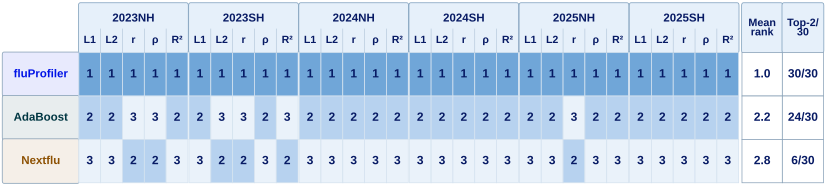

Wrote outputs to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig2_seasonal_rank


In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
values.to_csv(OUTPUT_DIR / 'Fig2D_seasonal_metric_ranks.csv', index=False)
fig2d.draw_rank_matrix(values, OUTPUT_DIR)
display(SVG(filename=str(OUTPUT_DIR / 'Fig2D_SeasonalRank.svg')))
print(f'Wrote outputs to: {OUTPUT_DIR}')

## Supplementary analysis: seasonal ranking with identity-aware baselines

This sensitivity analysis retains the identity-free fluProfiler predictions but evaluates AdaBoost and Nextflu using their saved identity-aware (`with-name`) predictions. It therefore asks whether fluProfiler remains competitive when the two baselines are allowed to use serum- and virus-identity terms. The analysis uses the same six seasonal test partitions, five metrics and ranking rules as Fig. 2D. The outputs are intended for a Supplementary Figure rather than replacement of the identity-masked main-text comparison.

In [5]:
WITH_NAME_OUTPUT_DIR = CODE_DIR / 'FigS_seasonal_rank_identity_aware'


def with_name_prediction_file(results_root, model, season):
    if model == 'fluProfiler':
        return (
            results_root / f'SCMS-FiLM-H3/season/{season}/subtype/H3N2_seed42/predictions_test.csv',
            'mean',
            None,
        )
    if model == 'AdaBoost':
        return (
            results_root / f'Adaboost/season/{season}/H3N2/predictions.csv',
            'prediction',
            "split == 'test'",
        )
    if model == 'Nextflu':
        return (
            results_root / f'Nextflu/season/{season}/H3N2/predictions.csv',
            'pred_with_name',
            None,
        )
    raise ValueError(f'Unsupported model: {model}')


def collect_identity_aware_baseline_metrics(results_root):
    rows = []
    for season, season_label in fig2d.SEASONS.items():
        for model in fig2d.MODELS:
            path, prediction_column, query_expression = with_name_prediction_file(
                results_root, model, season
            )
            if not path.is_file():
                raise FileNotFoundError(path)
            frame = pd.read_csv(path)
            if query_expression:
                frame = frame.query(query_expression).copy()
            required = {'label', prediction_column}
            if missing := required.difference(frame.columns):
                raise ValueError(f'{path} lacks columns: {sorted(missing)}')
            metrics = fig2d.compute_metrics(frame, prediction_column)
            for metric, value in metrics.items():
                rows.append({
                    'season_id': season,
                    'season': season_label,
                    'model': model,
                    'identity_setting': (
                        'identity-free' if model == 'fluProfiler' else 'identity-aware'
                    ),
                    'prediction_column': prediction_column,
                    'metric': metric,
                    'value': value,
                    'n_test_pairs': len(frame),
                })

    metrics = pd.DataFrame(rows)
    metrics['rank'] = 0
    for metric in fig2d.METRICS:
        mask = metrics['metric'].eq(metric)
        metrics.loc[mask, 'rank'] = (
            metrics.loc[mask]
            .groupby('season')['value']
            .rank(method='min', ascending=metric not in fig2d.HIGHER_BETTER)
        )
    metrics['rank'] = metrics['rank'].astype(int)
    return metrics


seasonal_metrics_with_name = collect_identity_aware_baseline_metrics(RESULTS_ROOT)

assert len(seasonal_metrics_with_name) == 90
rank_sets = (
    seasonal_metrics_with_name.groupby(['season', 'metric'])['rank']
    .apply(lambda values: sorted(values.tolist()))
)
assert rank_sets.map(lambda values: values == [1, 2, 3]).all()

display(seasonal_metrics_with_name)
display(
    seasonal_metrics_with_name.pivot(
        index=['season', 'metric'], columns='model', values='rank'
    )
)

with_name_rank_summary = (
    seasonal_metrics_with_name.groupby(['model', 'identity_setting'])['rank']
    .agg(
        mean_rank='mean',
        top2_count=lambda values: int((values <= 2).sum()),
        first_place_count=lambda values: int((values == 1).sum()),
    )
    .reset_index()
)
display(with_name_rank_summary)

,season_id,season,model,identity_setting,prediction_column,metric,value,n_test_pairs,rank
0,39,2023NH,fluProfiler,identity-free,mean,MAE,0.9318,3432,2
1,39,2023NH,fluProfiler,identity-free,mean,MSE,1.3709,3432,2
2,39,2023NH,fluProfiler,identity-free,mean,Pearson,0.6278,3432,2
3,39,2023NH,fluProfiler,identity-free,mean,Spearman,0.6096,3432,2
4,39,2023NH,fluProfiler,identity-free,mean,R2,0.2843,3432,2
...,...,...,...,...,...,...,...,...,...
85,44,2025SH,Nextflu,identity-aware,pred_with_name,MAE,1.5841,2649,3
86,44,2025SH,Nextflu,identity-aware,pred_with_name,MSE,5.2078,2649,3
87,44,2025SH,Nextflu,identity-aware,pred_with_name,Pearson,0.3984,2649,3
88,44,2025SH,Nextflu,identity-aware,pred_with_name,Spearman,0.3117,2649,3


model            AdaBoost  Nextflu  fluProfiler
season metric                                  
2023NH MAE              3        1            2
       MSE              3        1            2
       Pearson          3        1            2
       R2               3        1            2
       Spearman         3        1            2
2023SH MAE              1        3            2
       MSE              3        1            2
       Pearson          3        2            1
       R2               3        1            2
       Spearman         2        3            1
2024NH MAE              1        3            2
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         1        3            2
2024SH MAE              2        3            1
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         2        3            1
2025NH MAE              1        3            2
       MSE              2        3            1
       Pearson          3        2            1
       R2               2        3            1
       Spearman         2        3            1
2025SH MAE              2        3            1
       MSE              2        3            1
       Pearson          2        3            1
       R2               2        3            1
       Spearman         2        3            1

,model,identity_setting,mean_rank,top2_count,first_place_count
0,AdaBoost,identity-aware,2.1667,21,4
1,Nextflu,identity-aware,2.4667,9,7
2,fluProfiler,identity-free,1.3667,30,19


### Export the Supplementary Figure and 90-row source table

The figure labels explicitly identify AdaBoost and Nextflu as `with name`. Output names use `FigS` as a placeholder until the final Supplementary Figure order is fixed.

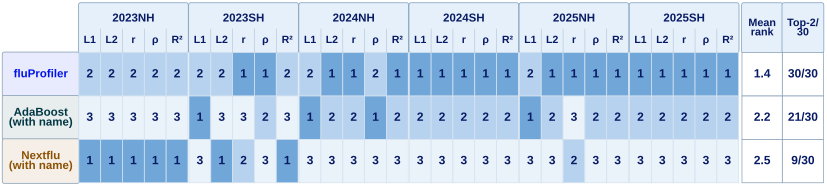

Wrote 90-row metrics table: /home/chenyh/workspace/fluProfiler/paper/Code/FigS_seasonal_rank_identity_aware/FigS_seasonal_metric_ranks_identity_aware.csv
Wrote rank summary: /home/chenyh/workspace/fluProfiler/paper/Code/FigS_seasonal_rank_identity_aware/FigS_seasonal_rank_summary_identity_aware.csv
Wrote Supplementary Figure files: /home/chenyh/workspace/fluProfiler/paper/Code/FigS_seasonal_rank_identity_aware/FigS_SeasonalRank_IdentityAwareBaselines.[svg|pdf|png]


In [6]:
WITH_NAME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = WITH_NAME_OUTPUT_DIR / 'FigS_seasonal_metric_ranks_identity_aware.csv'
summary_path = WITH_NAME_OUTPUT_DIR / 'FigS_seasonal_rank_summary_identity_aware.csv'
seasonal_metrics_with_name.to_csv(metrics_path, index=False)
with_name_rank_summary.to_csv(summary_path, index=False)

original_display_names = fig2d.DISPLAY_NAMES.copy()
fig2d.DISPLAY_NAMES.update({
    'AdaBoost': 'AdaBoost\n(with name)',
    'Nextflu': 'Nextflu\n(with name)',
})
try:
    fig2d.draw_rank_matrix(seasonal_metrics_with_name, WITH_NAME_OUTPUT_DIR)
finally:
    fig2d.DISPLAY_NAMES.clear()
    fig2d.DISPLAY_NAMES.update(original_display_names)

generated_stem = WITH_NAME_OUTPUT_DIR / 'Fig2D_SeasonalRank'
supplementary_stem = WITH_NAME_OUTPUT_DIR / 'FigS_SeasonalRank_IdentityAwareBaselines'
for extension in ('svg', 'pdf', 'png'):
    generated = generated_stem.with_suffix(f'.{extension}')
    destination = supplementary_stem.with_suffix(f'.{extension}')
    destination.unlink(missing_ok=True)
    generated.replace(destination)

display(SVG(filename=str(supplementary_stem.with_suffix('.svg'))))
print(f'Wrote 90-row metrics table: {metrics_path}')
print(f'Wrote rank summary: {summary_path}')
print(f'Wrote Supplementary Figure files: {supplementary_stem}.[svg|pdf|png]')